## Проверка GPU

In [25]:
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)

CUDA available: True
GPU: Tesla T4
CUDA version: 12.8


## Зависимости

`nvidia-ml-py` нужен для чтения мощности GPU через NVML.

In [26]:
%pip install -q nvidia-ml-py scipy

## Импорты и воспроизводимость

In [27]:
import gc
import json
import random
import sys
import threading
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.optimize import least_squares, lsq_linear

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.allow_tf32 = False
torch.backends.cuda.matmul.allow_tf32 = False

assert torch.cuda.is_available(), "Для измерений нужно подключить GPU в Colab"
device = torch.device("cuda")

## Файлы проекта

Перед запуском загрузите папку `hw1` в `/content`. В ней должны находиться `models.py` и `equations.py`.

In [28]:
project_path = Path("/content/hw1")

assert (project_path / "models.py").exists(), "Не найден /content/hw1/models.py"
assert (project_path / "equations.py").exists(), "Не найден /content/hw1/equations.py"

if "/content" not in sys.path:
    sys.path.insert(0, "/content")

print("Файлы проекта найдены:", project_path)

Файлы проекта найдены: /content/hw1


## Модель и аналитические формулы

In [29]:
from hw1.models import SmallCNN
from hw1.equations import bytes_moved, energy, flops, latency, memory

model = SmallCNN().to(device).eval()

parameter_count = sum(parameter.numel() for parameter in model.parameters())
parameter_bytes = sum(
    parameter.numel() * parameter.element_size()
    for parameter in model.parameters()
)

print(f"Параметров: {parameter_count:,}")
print(f"Память весов: {parameter_bytes / 1024**2:.4f} MiB")

Параметров: 1,040,324
Память весов: 3.9685 MiB


## Сетка экспериментов

In [31]:
base_image_sizes = [32, 64, 128, 224, 256, 384, 512]
base_batches = [1, 2, 4, 8, 16, 32, 64, 128, 256]

all_image_sizes = list(range(32, 513, 16))
all_batches = list(range(1, 257))

extra_image_sizes = random.sample(
    [value for value in all_image_sizes if value not in base_image_sizes],
    4,
)
extra_batches = random.sample(
    [value for value in all_batches if value not in base_batches],
    3,
)

image_sizes = sorted(base_image_sizes + extra_image_sizes)
batch_sizes = sorted(base_batches + extra_batches)

print("Image sizes:", image_sizes)
print("Batch sizes:", batch_sizes)
print("Всего конфигураций:", len(image_sizes) * len(batch_sizes))

Image sizes: [32, 64, 112, 128, 144, 224, 256, 384, 464, 496, 512]
Batch sizes: [1, 2, 4, 8, 16, 32, 64, 128, 148, 198, 237, 256]
Всего конфигураций: 132


In [32]:
configurations = pd.DataFrame(
    [(image_size, batch) for image_size in image_sizes for batch in batch_sizes],
    columns=["image_size", "batch"],
)

split_rng = np.random.default_rng(SEED)
configurations["is_validation"] = split_rng.random(len(configurations)) < 0.5

print("Calibration:", (~configurations["is_validation"]).sum())
print("Validation:", configurations["is_validation"].sum())
configurations.head()

Calibration: 62
Validation: 70


,image_size,batch,is_validation
0,32,1,False
1,32,2,True
2,32,4,False
3,32,8,False
4,32,16,True


## Измерение memory, latency и energy

In [33]:
from pynvml import (
    nvmlDeviceGetHandleByIndex,
    nvmlDeviceGetName,
    nvmlDeviceGetPowerUsage,
    nvmlInit,
    nvmlShutdown,
)

WARMUP_STEPS = 3
LATENCY_STEPS = 20
ENERGY_TARGET_SECONDS = 0.5
ENERGY_MIN_REPEATS = 5
ENERGY_MAX_REPEATS = 500
POWER_SAMPLE_INTERVAL = 0.01

results_dir = project_path / "results"
figures_dir = results_dir / "figures"
results_dir.mkdir(exist_ok=True)
figures_dir.mkdir(exist_ok=True)
measurements_path = results_dir / "measurements.csv"

nvmlInit()
nvml_handle = nvmlDeviceGetHandleByIndex(0)
gpu_name = nvmlDeviceGetName(nvml_handle)
if isinstance(gpu_name, bytes):
    gpu_name = gpu_name.decode()

print("NVML GPU:", gpu_name)

NVML GPU: Tesla T4


In [34]:
def read_power_watts():
    """Текущая полная мощность GPU в ваттах."""
    return nvmlDeviceGetPowerUsage(nvml_handle) / 1000


def measure_energy(input_tensor, one_forward_latency):
    """Средняя энергия одного forward pass в джоулях."""
    repeats = int(np.ceil(ENERGY_TARGET_SECONDS / one_forward_latency))
    repeats = int(np.clip(repeats, ENERGY_MIN_REPEATS, ENERGY_MAX_REPEATS))

    power_samples = []
    stop_event = threading.Event()

    def sample_power():
        while not stop_event.is_set():
            power_samples.append((time.perf_counter(), read_power_watts()))
            stop_event.wait(POWER_SAMPLE_INTERVAL)

    torch.cuda.synchronize()
    start_time = time.perf_counter()
    power_samples.append((start_time, read_power_watts()))

    sampler = threading.Thread(target=sample_power)
    sampler.start()
    energy_output = None

    try:
        with torch.inference_mode():
            for _ in range(repeats):
                energy_output = model(input_tensor)
        torch.cuda.synchronize()
        end_time = time.perf_counter()
    finally:
        stop_event.set()
        sampler.join()

    power_samples.append((end_time, read_power_watts()))
    del energy_output

    samples_inside_interval = [
        sample
        for sample in power_samples
        if start_time <= sample[0] <= end_time
    ]
    samples_inside_interval.sort()

    sample_times = np.array([sample[0] for sample in samples_inside_interval])
    sample_powers = np.array([sample[1] for sample in samples_inside_interval])

    total_energy = np.trapezoid(sample_powers, sample_times)
    energy_per_forward = total_energy / repeats

    return energy_per_forward, repeats


def measure_configuration(image_size, batch):
    """Измеряет memory, latency и energy для одной конфигурации."""
    gc.collect()
    torch.cuda.empty_cache()

    input_tensor = torch.randn(
        batch, 3, image_size, image_size,
        device=device,
    )

    with torch.inference_mode():
        for _ in range(WARMUP_STEPS):
            warmup_output = model(input_tensor)
    torch.cuda.synchronize()
    del warmup_output

    torch.cuda.reset_peak_memory_stats()
    with torch.inference_mode():
        memory_output = model(input_tensor)
    torch.cuda.synchronize()
    peak_memory_bytes = torch.cuda.max_memory_allocated()
    del memory_output

    latency_values = []
    with torch.inference_mode():
        for _ in range(LATENCY_STEPS):
            torch.cuda.synchronize()
            start_time = time.perf_counter()
            latency_output = model(input_tensor)
            torch.cuda.synchronize()
            latency_values.append(time.perf_counter() - start_time)
            del latency_output

    median_latency = float(np.median(latency_values))
    energy_joules, energy_repeats = measure_energy(
        input_tensor,
        median_latency,
    )

    del input_tensor
    gc.collect()
    torch.cuda.empty_cache()

    return {
        "latency_s": median_latency,
        "memory_bytes": peak_memory_bytes,
        "energy_j": energy_joules,
        "energy_repeats": energy_repeats,
    }

In [35]:
measurement_rows = []

for row_number, configuration in configurations.iterrows():
    image_size = int(configuration["image_size"])
    batch = int(configuration["batch"])

    result_row = {
        "image_size": image_size,
        "batch": batch,
        "is_validation": bool(configuration["is_validation"]),
        "predicted_flops": float(flops(image_size, batch)),
        "predicted_memory_bytes": float(memory(image_size, batch)),
        "predicted_bytes_moved": float(bytes_moved(image_size, batch)),
    }

    try:
        measured = measure_configuration(image_size, batch)
        result_row.update(measured)
        result_row["status"] = "OK"

        print(
            f"[{row_number + 1:3d}/{len(configurations)}] "
            f"S={image_size:3d}, B={batch:3d}: "
            f"{measured['latency_s'] * 1000:8.3f} ms, "
            f"{measured['memory_bytes'] / 1024**2:9.2f} MiB, "
            f"{measured['energy_j'] * 1000:9.3f} mJ"
        )

    except torch.cuda.OutOfMemoryError:
        result_row.update({
            "latency_s": np.nan,
            "memory_bytes": np.nan,
            "energy_j": np.nan,
            "energy_repeats": 0,
            "status": "OOM",
        })
        gc.collect()
        torch.cuda.empty_cache()
        print(
            f"[{row_number + 1:3d}/{len(configurations)}] "
            f"S={image_size:3d}, B={batch:3d}: OOM"
        )

    measurement_rows.append(result_row)

    # После каждой точки сохраняем checkpoint, чтобы не потерять долгий прогон.
    pd.DataFrame(measurement_rows).to_csv(measurements_path, index=False)

nvmlShutdown()
measurements = pd.DataFrame(measurement_rows)
print("Сохранено:", measurements_path)

[  1/132] S= 32, B=  1:    0.696 ms,     17.89 MiB,    19.925 mJ
[  2/132] S= 32, B=  2:    0.507 ms,     18.00 MiB,    25.698 mJ
[  3/132] S= 32, B=  4:    0.500 ms,     18.21 MiB,    28.613 mJ
[  4/132] S= 32, B=  8:    0.521 ms,     18.63 MiB,    31.341 mJ
[  5/132] S= 32, B= 16:    0.487 ms,     14.16 MiB,    30.178 mJ
[  6/132] S= 32, B= 32:    0.590 ms,     15.22 MiB,    36.698 mJ
[  7/132] S= 32, B= 64:    0.727 ms,     17.59 MiB,    58.493 mJ
[  8/132] S= 32, B=128:    2.105 ms,     57.34 MiB,   154.064 mJ
[  9/132] S= 32, B=148:    2.333 ms,     63.97 MiB,   173.907 mJ
[ 10/132] S= 32, B=198:    3.186 ms,     79.60 MiB,   251.257 mJ
[ 11/132] S= 32, B=237:    4.071 ms,     93.28 MiB,   281.227 mJ
[ 12/132] S= 32, B=256:    4.508 ms,     98.87 MiB,   306.082 mJ
[ 13/132] S= 64, B=  1:    0.535 ms,     22.13 MiB,    34.861 mJ
[ 14/132] S= 64, B=  2:    0.541 ms,     22.67 MiB,    36.417 mJ
[ 15/132] S= 64, B=  4:    0.517 ms,     23.75 MiB,    42.778 mJ
[ 16/132] S= 64, B=  8:  

In [37]:
measurements["measured_memory_mib"] = measurements["memory_bytes"] / 1024**2
measurements["formula_memory_mib"] = measurements["predicted_memory_bytes"] / 1024**2
measurements["memory_difference_mib"] = (
    measurements["measured_memory_mib"]
    - measurements["formula_memory_mib"]
)

print(measurements["status"].value_counts())
display(
    measurements[[
        "image_size",
        "batch",
        "status",
        "latency_s",
        "measured_memory_mib",
        "formula_memory_mib",
        "energy_j",
        "is_validation",
    ]].head(50)
)

status
OK    132
Name: count, dtype: int64


,image_size,batch,status,latency_s,measured_memory_mib,formula_memory_mib,energy_j,is_validation
0,32,1,OK,0.000696,17.894531,4.019302,0.019925,False
1,32,2,OK,0.000507,18.000000,4.070084,0.025698,True
2,32,4,OK,0.000500,18.210938,4.171646,0.028613,False
3,32,8,OK,0.000521,18.632812,4.374771,0.031341,False
4,32,16,OK,0.000487,14.156250,4.781021,0.030178,True
5,32,32,OK,0.000590,15.218750,5.593521,0.036698,False
6,32,64,OK,0.000727,17.593750,7.218521,0.058493,False
7,32,128,OK,0.002105,57.343750,10.468521,0.154064,False
8,32,148,OK,0.002333,63.968750,11.484146,0.173907,True
9,32,198,OK,0.003186,79.601562,14.023209,0.251257,True


## Подбор параметров $\theta$

Параметры подбираются **только** по успешным calibration-точкам. Validation-точки не участвуют в оптимизации.

Для latency оптимизируются положительные параметры:

- `launch_latency` — цена одного запуска CUDA-ядра;
- `compute_rate` — эффективная производительность в FLOP/s;
- `memory_bandwidth` — эффективная пропускная способность в byte/s.

Оптимизация идёт в логарифмах, поэтому все три параметра остаются положительными. Для energy после этого неотрицательным least squares подбираются $P_0$, $e_F$ и $e_B$.

In [38]:
successful = measurements[measurements["status"] == "OK"].copy()
calibration = successful[~successful["is_validation"]].copy()
validation = successful[successful["is_validation"]].copy()

calibration_image_sizes = calibration["image_size"].to_numpy()
calibration_batches = calibration["batch"].to_numpy()
measured_calibration_latency = calibration["latency_s"].to_numpy()

def unpack_latency_parameters(log_parameters):
    values = np.exp(log_parameters)
    return {
        "launch_latency": values[0],
        "compute_rate": values[1],
        "memory_bandwidth": values[2],
    }

def latency_residuals(log_parameters):
    candidate_theta = unpack_latency_parameters(log_parameters)
    predicted = latency(
        calibration_image_sizes,
        calibration_batches,
        candidate_theta,
    )
    return np.log(predicted) - np.log(measured_calibration_latency)

initial_latency_parameters = np.array([
    5e-6,
    5e12,
    2e11,
])
lower_bounds = np.array([1e-8, 1e9, 1e8])
upper_bounds = np.array([1e-3, 1e14, 1e13])

latency_fit = least_squares(
    latency_residuals,
    np.log(initial_latency_parameters),
    bounds=(np.log(lower_bounds), np.log(upper_bounds)),
)
theta_latency = unpack_latency_parameters(latency_fit.x)

print(f"launch_latency:  {theta_latency['launch_latency'] * 1e6:.3f} us")
print(f"compute_rate:     {theta_latency['compute_rate'] / 1e12:.3f} TFLOP/s")
print(f"memory_bandwidth: {theta_latency['memory_bandwidth'] / 1e9:.3f} GB/s")

launch_latency:  22.993 us
compute_rate:     5.577 TFLOP/s
memory_bandwidth: 72.466 GB/s


In [39]:
calibration_latency_prediction = latency(
    calibration_image_sizes,
    calibration_batches,
    theta_latency,
)

# Giga-единицы улучшают численную устойчивость least squares.
energy_features = np.column_stack([
    calibration_latency_prediction,
    calibration["predicted_flops"].to_numpy() / 1e9,
    calibration["predicted_bytes_moved"].to_numpy() / 1e9,
])
measured_calibration_energy = calibration["energy_j"].to_numpy()

energy_fit = lsq_linear(
    energy_features,
    measured_calibration_energy,
    bounds=(0, np.inf),
)
energy_coefficients = energy_fit.x

theta_energy = {
    "base_power": float(energy_coefficients[0]),
    "energy_per_flop": float(energy_coefficients[1] / 1e9),
    "energy_per_byte": float(energy_coefficients[2] / 1e9),
    "latency_theta": theta_latency,
}

print(f"base_power:       {theta_energy['base_power']:.3f} W")
print(f"energy_per_flop:  {theta_energy['energy_per_flop']:.3e} J/FLOP")
print(f"energy_per_byte:  {theta_energy['energy_per_byte']:.3e} J/byte")

base_power:       0.000 W
energy_per_flop:  3.113e-11 J/FLOP
energy_per_byte:  2.980e-26 J/byte


In [40]:
all_image_sizes_array = measurements["image_size"].to_numpy()
all_batches_array = measurements["batch"].to_numpy()

measurements["predicted_latency_s"] = latency(
    all_image_sizes_array,
    all_batches_array,
    theta_latency,
)
measurements["predicted_energy_j"] = energy(
    all_image_sizes_array,
    all_batches_array,
    theta_energy,
)

launch_component = np.full(
    len(measurements),
    17 * theta_latency["launch_latency"],
)
compute_component = measurements["predicted_flops"].to_numpy() / theta_latency["compute_rate"]
memory_component = measurements["predicted_bytes_moved"].to_numpy() / theta_latency["memory_bandwidth"]

component_names = np.array(["launch-bound", "compute-bound", "memory-bound"])
measurements["dominant_regime"] = component_names[
    np.argmax(
        np.column_stack([launch_component, compute_component, memory_component]),
        axis=1,
    )
]

measurements.to_csv(measurements_path, index=False)

theta_path = results_dir / "theta.json"
theta_to_save = {
    "latency": {key: float(value) for key, value in theta_latency.items()},
    "energy": {
        "base_power": theta_energy["base_power"],
        "energy_per_flop": theta_energy["energy_per_flop"],
        "energy_per_byte": theta_energy["energy_per_byte"],
    },
}
with theta_path.open("w") as file:
    json.dump(theta_to_save, file, indent=2)

print("Обновлён:", measurements_path)
print("Сохранён:", theta_path)

Обновлён: /content/hw1/results/measurements.csv
Сохранён: /content/hw1/results/theta.json


## Ошибка на calibration и validation

MAE показывается в естественных единицах каждой величины. MAPE и median APE позволяют сравнить относительную ошибку на calibration и на данных, которые модель не видела при подборе параметров.

In [41]:
def calculate_errors(data, measured_column, predicted_column, unit_scale):
    measured_values = data[measured_column].to_numpy() * unit_scale
    predicted_values = data[predicted_column].to_numpy() * unit_scale

    absolute_errors = np.abs(predicted_values - measured_values)
    percentage_errors = absolute_errors / measured_values * 100

    return {
        "MAE": absolute_errors.mean(),
        "MAPE, %": percentage_errors.mean(),
        "Median APE, %": np.median(percentage_errors),
    }

metric_definitions = [
    ("Latency, ms", "latency_s", "predicted_latency_s", 1000),
    ("Memory, MiB", "memory_bytes", "predicted_memory_bytes", 1 / 1024**2),
    ("Energy, mJ", "energy_j", "predicted_energy_j", 1000),
]

error_rows = []
for split_name, split_data in [("calibration", calibration), ("validation", validation)]:
    split_with_predictions = measurements.loc[split_data.index]

    for metric_name, measured_column, predicted_column, scale in metric_definitions:
        errors = calculate_errors(
            split_with_predictions,
            measured_column,
            predicted_column,
            scale,
        )
        error_rows.append({
            "split": split_name,
            "metric": metric_name,
            **errors,
        })

error_table = pd.DataFrame(error_rows)
display(error_table.round(3))

,split,metric,MAE,"MAPE, %","Median APE, %"
0,calibration,"Latency, ms",15.408,28.488,22.630
1,calibration,"Memory, MiB",344.412,50.947,46.588
2,calibration,"Energy, mJ",260.017,31.742,28.948
3,validation,"Latency, ms",14.291,30.297,22.648
4,validation,"Memory, MiB",332.281,50.718,48.064
5,validation,"Energy, mJ",339.398,28.378,23.341


## Графики: предсказание против измерения

В первых трёх графиках каждая точка — реальная конфигурация. Чем ближе она к диагонали, тем точнее формула. Calibration и validation показаны разными маркерами. Затем те же результаты показаны как аналитические поверхности с наложенными измеренными точками.

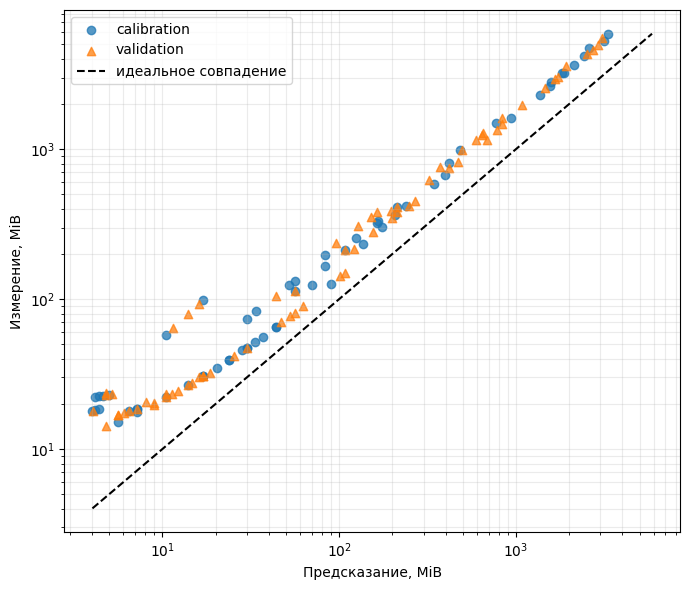

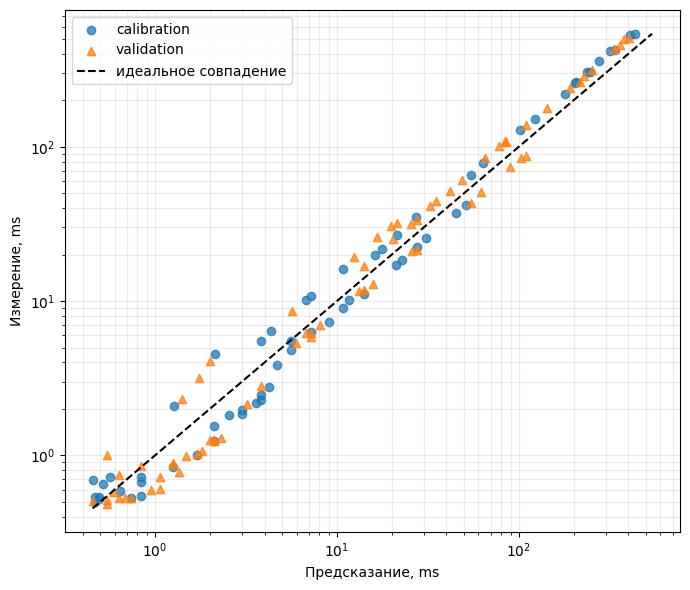

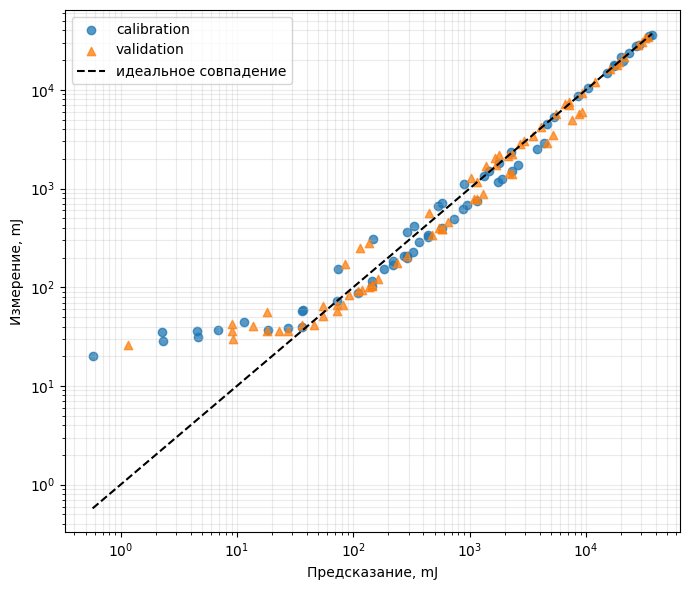

In [42]:
def plot_measured_vs_predicted(
    measured_column,
    predicted_column,
    divisor,
    axis_label,
    file_name,
):
    figure, axis = plt.subplots(figsize=(7, 6))

    for is_validation, marker, label in [
        (False, "o", "calibration"),
        (True, "^", "validation"),
    ]:
        points = successful[successful["is_validation"] == is_validation]
        points = measurements.loc[points.index]
        axis.scatter(
            points[predicted_column] / divisor,
            points[measured_column] / divisor,
            marker=marker,
            alpha=0.75,
            label=label,
        )

    positive_points = measurements[measurements["status"] == "OK"]
    all_values = np.concatenate([
        positive_points[measured_column].to_numpy() / divisor,
        positive_points[predicted_column].to_numpy() / divisor,
    ])
    diagonal_min = all_values.min()
    diagonal_max = all_values.max()
    axis.plot(
        [diagonal_min, diagonal_max],
        [diagonal_min, diagonal_max],
        "k--",
        label="идеальное совпадение",
    )

    axis.set_xscale("log")
    axis.set_yscale("log")
    axis.set_xlabel(f"Предсказание, {axis_label}")
    axis.set_ylabel(f"Измерение, {axis_label}")
    axis.grid(True, which="both", alpha=0.25)
    axis.legend()
    figure.tight_layout()
    figure.savefig(figures_dir / file_name, dpi=160)
    plt.show()

plot_measured_vs_predicted("memory_bytes", "predicted_memory_bytes", 1024**2, "MiB", "memory_parity.png")
plot_measured_vs_predicted("latency_s", "predicted_latency_s", 1e-3, "ms", "latency_parity.png")
plot_measured_vs_predicted("energy_j", "predicted_energy_j", 1e-3, "mJ", "energy_parity.png")

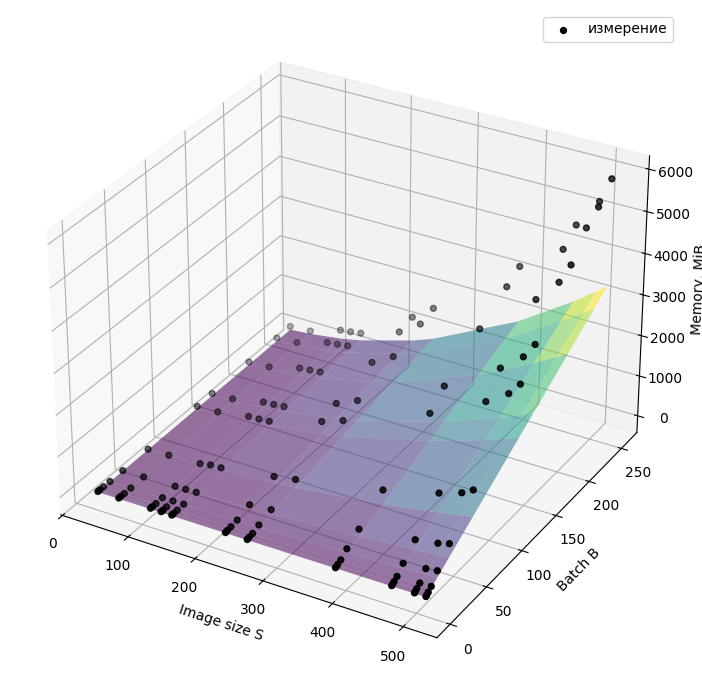

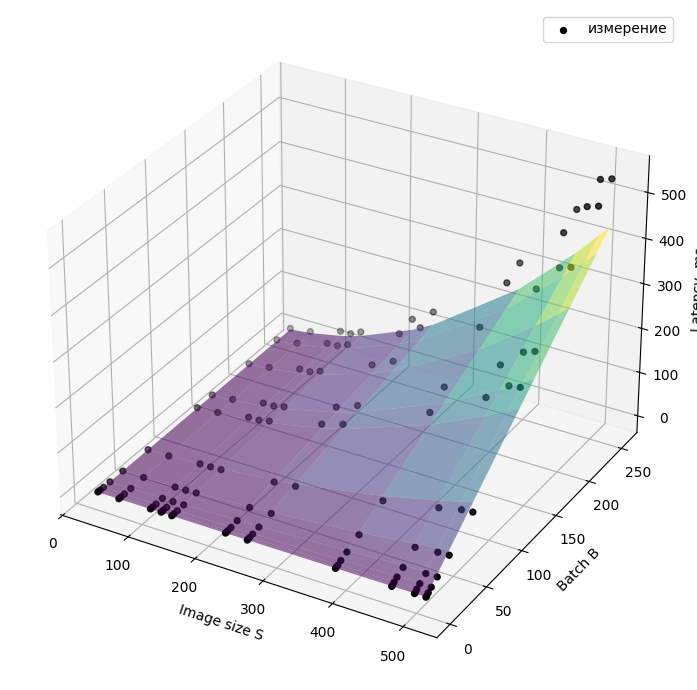

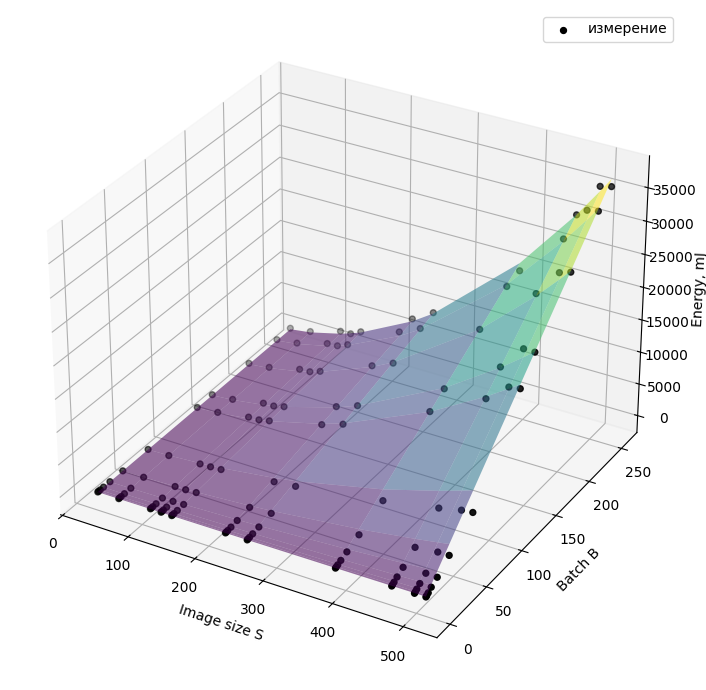

In [43]:
def plot_prediction_surface(
    measured_column,
    predicted_column,
    divisor,
    z_label,
    file_name,
):
    image_grid, batch_grid = np.meshgrid(
        image_sizes,
        batch_sizes,
        indexing="ij",
    )
    predicted_grid = (
        measurements
        .pivot(index="image_size", columns="batch", values=predicted_column)
        .reindex(index=image_sizes, columns=batch_sizes)
        .to_numpy()
        / divisor
    )

    figure = plt.figure(figsize=(9, 7))
    axis = figure.add_subplot(111, projection="3d")
    axis.plot_surface(
        image_grid, batch_grid, predicted_grid,
        cmap="viridis", alpha=0.55,
    )

    measured_points = measurements[measurements["status"] == "OK"]
    axis.scatter(
        measured_points["image_size"],
        measured_points["batch"],
        measured_points[measured_column] / divisor,
        color="black", s=18, label="измерение",
    )

    axis.set_xlabel("Image size S")
    axis.set_ylabel("Batch B")
    axis.set_zlabel(z_label)
    axis.legend()
    figure.tight_layout()
    figure.savefig(figures_dir / file_name, dpi=160)
    plt.show()

plot_prediction_surface("memory_bytes", "predicted_memory_bytes", 1024**2, "Memory, MiB", "memory_surface.png")
plot_prediction_surface("latency_s", "predicted_latency_s", 1e-3, "Latency, ms", "latency_surface.png")
plot_prediction_surface("energy_j", "predicted_energy_j", 1e-3, "Energy, mJ", "energy_surface.png")

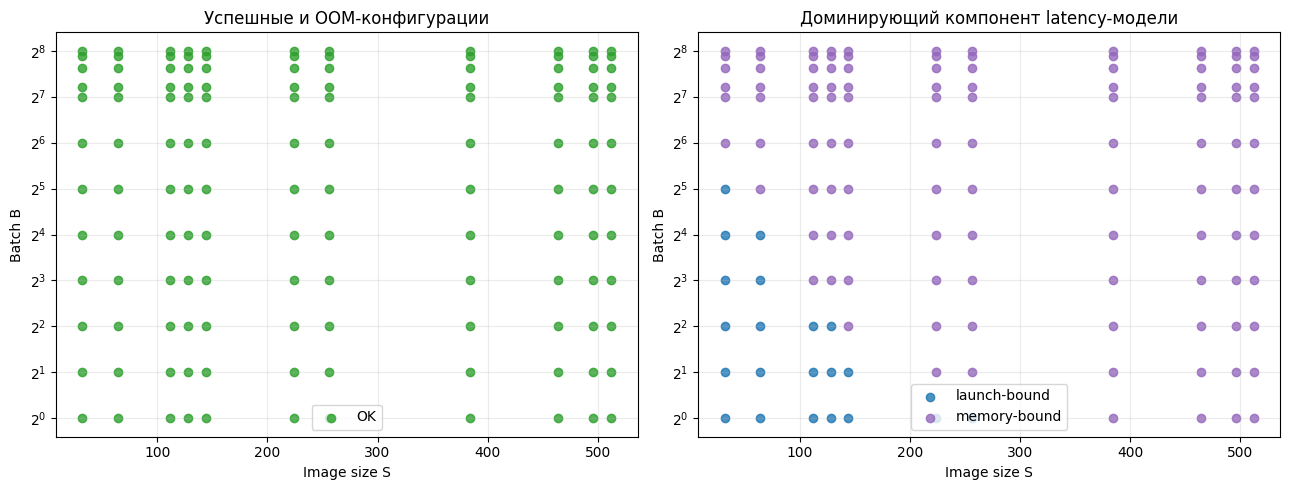

In [44]:
figure, axes = plt.subplots(1, 2, figsize=(13, 5))

status_colors = {"OK": "tab:green", "OOM": "tab:red"}
for status, points in measurements.groupby("status"):
    axes[0].scatter(
        points["image_size"], points["batch"],
        color=status_colors[status], label=status, alpha=0.8,
    )
axes[0].set_title("Успешные и OOM-конфигурации")
axes[0].set_xlabel("Image size S")
axes[0].set_ylabel("Batch B")
axes[0].set_yscale("log", base=2)
axes[0].grid(True, alpha=0.25)
axes[0].legend()

regime_colors = {
    "launch-bound": "tab:blue",
    "compute-bound": "tab:orange",
    "memory-bound": "tab:purple",
}
for regime, points in measurements.groupby("dominant_regime"):
    axes[1].scatter(
        points["image_size"], points["batch"],
        color=regime_colors[regime], label=regime, alpha=0.8,
    )
axes[1].set_title("Доминирующий компонент latency-модели")
axes[1].set_xlabel("Image size S")
axes[1].set_ylabel("Batch B")
axes[1].set_yscale("log", base=2)
axes[1].grid(True, alpha=0.25)
axes[1].legend()

figure.tight_layout()
figure.savefig(figures_dir / "oom_and_regimes.png", dpi=160)
plt.show()

## Интерпретация результатов

### 1. Memory
Все измеренные точки находятся выше диагонали на memory_parity.png, а на memory_surface.png чёрные точки систематически расположены выше аналитической поверхности. Следовательно, наша формула стабильно занижает реальный peak memory.

Основная причина занижения состоит в том, что аналитическая формула учитывает веса и выбранные тензоры сети, но не полностью описывает временные буферы и дополнительные выделения памяти PyTorch/cuDNN.

### 2. Latency
На latency_parity.png измеренные точки в целом располагаются вдоль диагонали, однако разброс остаётся заметным.

Модель хорошо описывает общий порядок величины и рост latency при увеличении \(S\) и \(B\), но не является точной: только около 27% validation-точек имеют ошибку не более 20%. Близкие ошибки на calibration и validation показывают, что параметры не переобучились на calibration-наборе, однако сама аналитическая модель остаётся приближённой.

### 3. Energy 
На больших \(S\) и \(B\) аналитическая поверхность energy располагается достаточно близко к измеренным точкам, поскольку для крупных конфигураций энергия почти пропорциональна количеству FLOPs.

Однако маленькие значения на трёхмерном графике визуально прижаты к нулю. Из-за этого energy_surface.png скрывает значительные относительные ошибки на небольших конфигурациях, где они достигают 97%. Поэтому по одной поверхности можно ошибочно заключить, что модель энергии очень точная.

Для корректной оценки необходимо рассматривать её вместе с energy_parity.png: модель хорошо описывает общий рост energy на крупных задачах, но плохо предсказывает небольшие конфигурации.